# Partie 2/3: Analyse des données images

In [43]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path) # Path to dataset files: C:\Users\clemm\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2

Path to dataset files: C:\Users\clemm\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2


In [45]:
path = r"C:\Users\clemm\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2"

In [46]:
df_attrs = pd.read_csv(os.path.join(path, "list_attr_celeba.csv"))

In [47]:
df_attrs

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202594,202595.jpg,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
202595,202596.jpg,-1,-1,-1,-1,-1,1,1,-1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
202596,202597.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
202597,202598.jpg,-1,1,1,-1,-1,-1,1,-1,1,...,-1,1,-1,1,1,-1,1,-1,-1,1


In [48]:
df_attrs.columns = ['Image_ID'] + list(df_attrs.columns[1:])

attribute_cols = df_attrs.columns[1:]
for col in attribute_cols:
    df_attrs[col] = (df_attrs[col] == 1).astype(int)

print(f"Dataset shape: {df_attrs.shape}")
print(f"Nombre d'images: {df_attrs.shape[0]}")
print(f"Nombre d'attributs: {len(attribute_cols)}")
print("\nAttributs disponibles:")
print(df_attrs.columns.tolist())

Dataset shape: (202599, 41)
Nombre d'images: 202599
Nombre d'attributs: 40

Attributs disponibles:
['Image_ID', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


## 1. Analyse du jeu de données

À l’aide de Python (matplotlib, seaborn, pandas) ,
- Analyse descriptive du jeu de données (Nombre total d’images, Nombre
de classes, Distribution par classe,...). Commenter.
- Analyse des corrélations entre attributs. Quelles sont les variables les
plus corrélées ? Exhiber au moins une corrélation artificielle. Commenter.
- Identification de variables sensibles (ex. Genre (male/female), Couleur
de peau, Âge, Contexte culturel. Justifier votre classification (pour sontelles sensibles ? …)
- Analyse de disparité: Certains groupes sont-ils sous-représentés ? Le
dataset reflète-t-il un biais de collecte ? Révèle-t-il d’autres biais ?
- Analyse de la fairness: nous allons nous intéresser aux deux métriques
de fairness ci-dessous. Elles se basent sur un attribut sensible (S) et
comparent avec un attribut à étudier (Y). Nous allons considérer deux
attributs sensibles: Male et Pale_Skin. Calculer la valeur de ces métriques
pour tous les autres attributs. Soit S l’attribut sensible et Y l’un des autres:

Demographic parity | P(Y=1 | S=1) - P(Y=1 | S=-1) |
Disparate impact P(Y=1 | S=1) / P(Y=1 | S=-1)

En particulier, s’intéresser à Y=Attractive et S=Pale_Skin. Commenter.

## 1.1 - Analyse Descriptive du jeu de données

In [49]:
df_attrs.head()

,Image_ID,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,0,1,1,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
1,000002.jpg,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
2,000003.jpg,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
3,000004.jpg,0,0,1,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
4,000005.jpg,0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1


Le dataset est codé en -1 et 1 avec -1 pour absent. On va les transformer en 0 et 1 pour l'analyse et simplifier le travail.

In [50]:
df_attrs = df_attrs.replace(-1, 0)

In [51]:
print(f"\nTotal d'images: {df_attrs.shape[0]}")
print(f"Nombre d'attributs: {len(attribute_cols)}")


Total d'images: 202599
Nombre d'attributs: 40


In [52]:
attr_distribution = df_attrs[attribute_cols].sum() / len(df_attrs) * 100
attr_distribution = attr_distribution.sort_values(ascending=False)

print("Distribution des attributs (% de cas positifs) :\n")
for attr, pct in attr_distribution.items():
    print(f"{attr:20s}: {pct:6.2f}% (n={int(df_attrs[attr].sum())})")

Distribution des attributs (% de cas positifs) :

No_Beard            :  83.49% (n=169158)
Young               :  77.36% (n=156734)
Attractive          :  51.25% (n=103833)
Mouth_Slightly_Open :  48.34% (n=97942)
Smiling             :  48.21% (n=97669)
Wearing_Lipstick    :  47.24% (n=95715)
High_Cheekbones     :  45.50% (n=92189)
Male                :  41.68% (n=84434)
Heavy_Makeup        :  38.69% (n=78390)
Wavy_Hair           :  31.96% (n=64744)
Oval_Face           :  28.41% (n=57567)
Pointy_Nose         :  27.74% (n=56210)
Arched_Eyebrows     :  26.70% (n=54090)
Big_Lips            :  24.08% (n=48785)
Black_Hair          :  23.93% (n=48472)
Big_Nose            :  23.45% (n=47516)
Straight_Hair       :  20.84% (n=42222)
Brown_Hair          :  20.52% (n=41572)
Bags_Under_Eyes     :  20.46% (n=41446)
Wearing_Earrings    :  18.89% (n=38276)
Bangs               :  15.16% (n=30709)
Blond_Hair          :  14.80% (n=29983)
Bushy_Eyebrows      :  14.22% (n=28803)
Wearing_Necklace    :  12.3

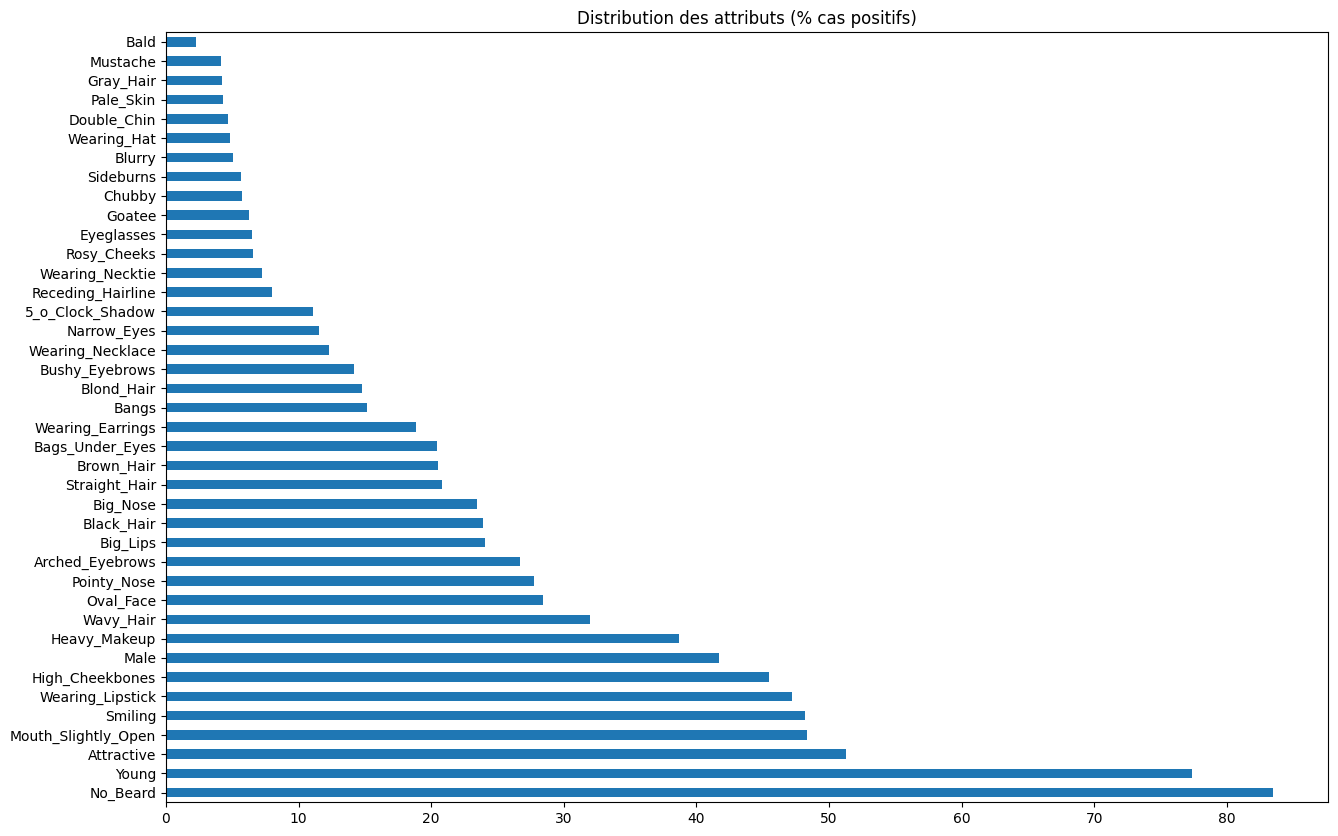

In [53]:
plt.figure(figsize=(15, 10))
attr_distribution.plot(kind='barh')
plt.title('Distribution des attributs (% cas positifs)')
plt.show()

Il y a un gros déséquilibre de classes. Il y a des attributs très dominants comme `No_Beard` ($83,49\%$) et `Young` ($77,36\%$) et d'autres très rare comme `Bald` ($2,24\%$), `Mustache` ($4,15\%$), `Pale_Skin` ($4,29\%$).

Il y a aussi possiblement un biais de célébrité. On observe que plus de la moitié des personnes sont jugées attractive, c'est une notion subjective qui ici reeflète le fait que ce sont des photos studio, retouchées et de personnes sélectionnées pour leur physique.

On observe aussi que la proportion de maquillage lourd est proche de la proportion de femmes. Il y aura donc probablement une corrélation forte entre le genre et certains attributs.

Par rapport à la variable cilble `Smiling` la classe est bien équilibrée.

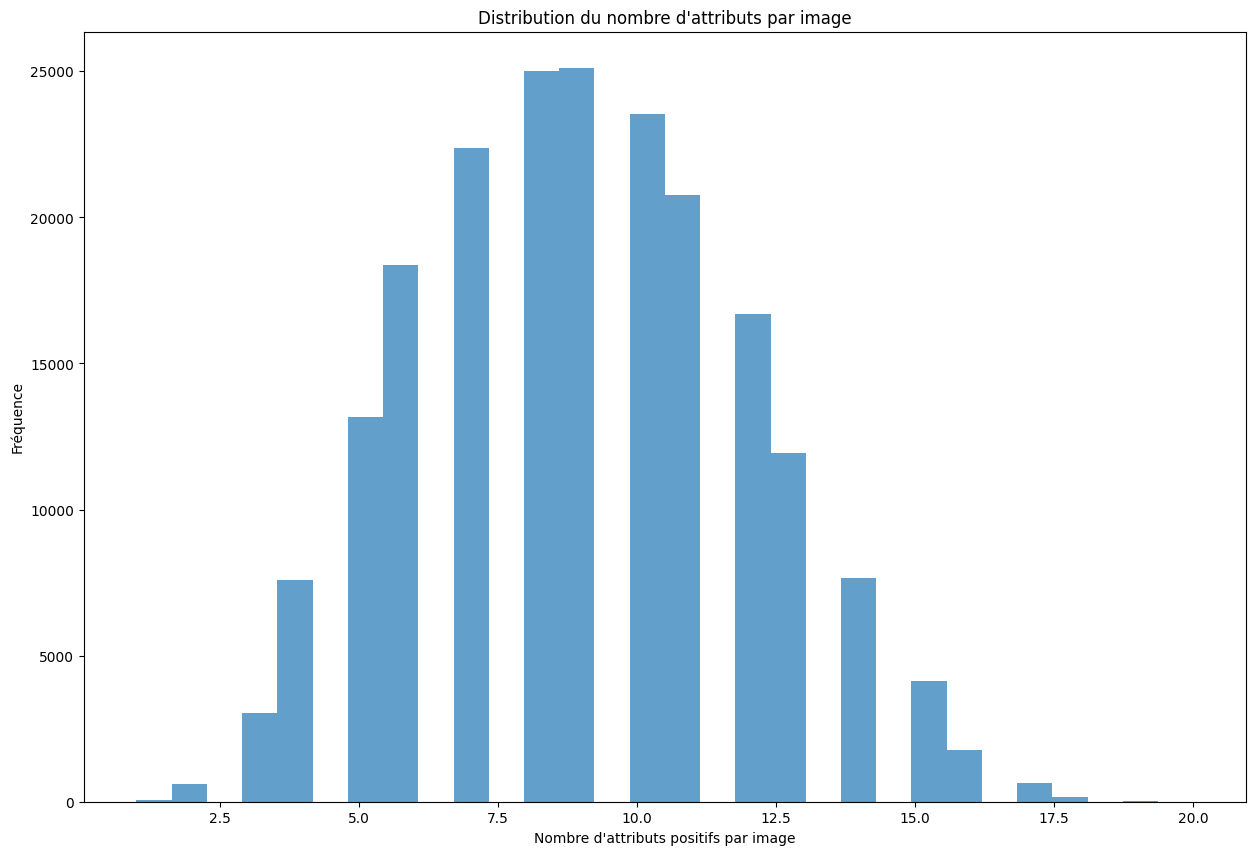

In [54]:
plt.figure(figsize=(15, 10))
n_attrs_per_image = df_attrs[attribute_cols].sum(axis=1)
plt.hist(n_attrs_per_image, bins=30, alpha=0.7)
plt.xlabel("Nombre d'attributs positifs par image")
plt.ylabel("Fréquence")
plt.title("Distribution du nombre d'attributs par image")
plt.show()

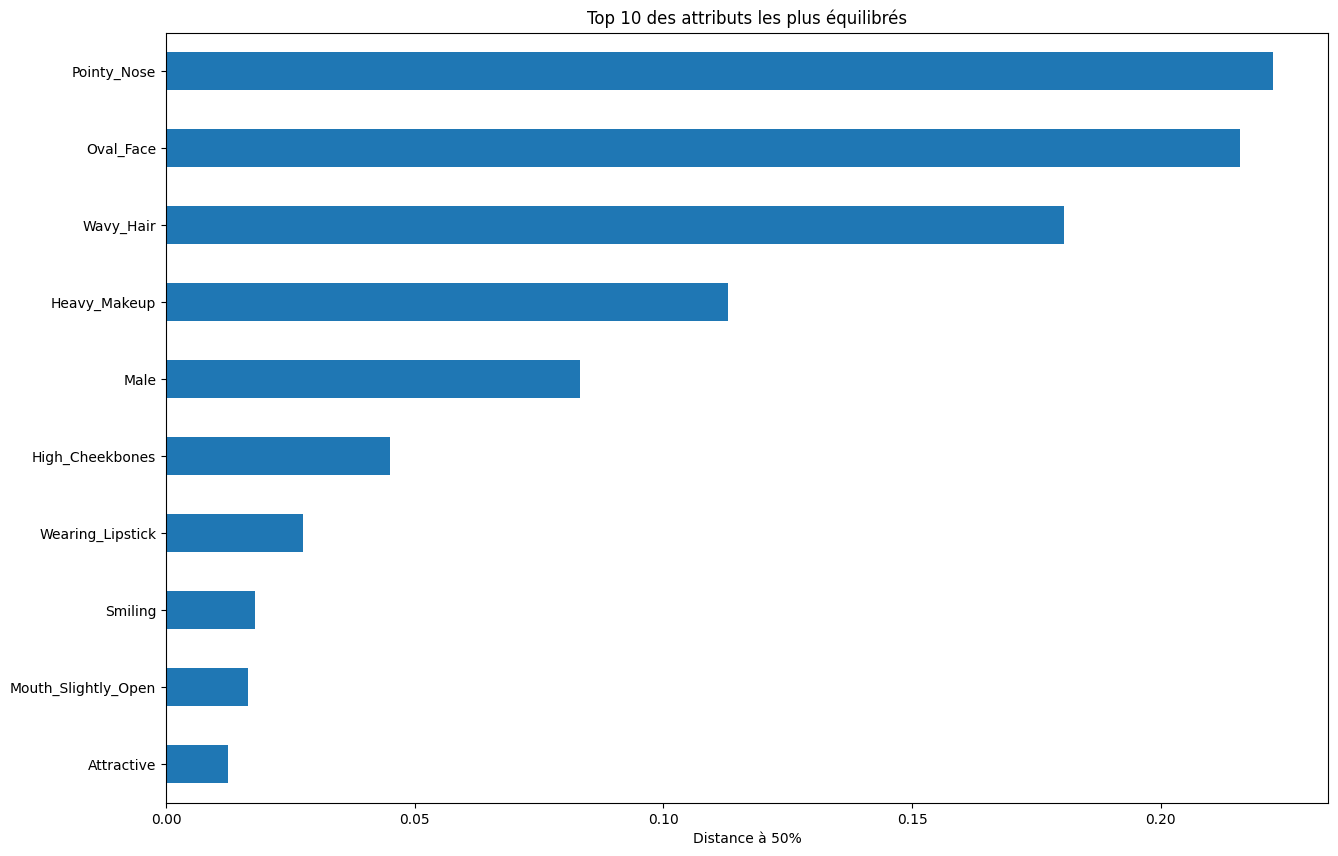

In [55]:
plt.figure(figsize=(15, 10))
balanced = (df_attrs[attribute_cols].sum() / len(df_attrs) - 0.5).abs().sort_values()[:10]
balanced.plot(kind='barh')
plt.xlabel('Distance à 50%')
plt.title('Top 10 des attributs les plus équilibrés')
plt.show()

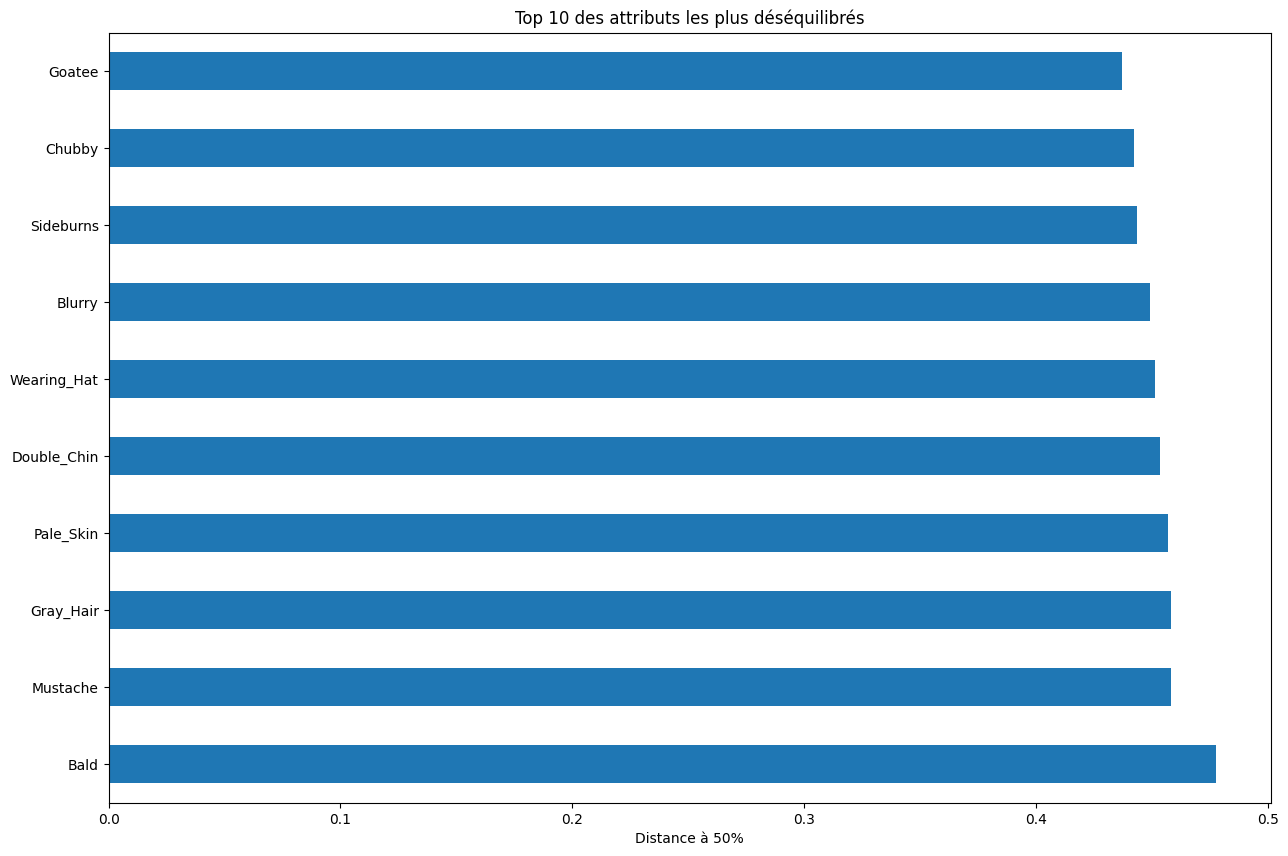

In [56]:
plt.figure(figsize=(15, 10))
imbalanced = (df_attrs[attribute_cols].sum() / len(df_attrs) - 0.5).abs().sort_values(ascending=False)[:10]
imbalanced.plot(kind='barh')
plt.xlabel('Distance à 50%')
plt.title('Top 10 des attributs les plus déséquilibrés')
plt.show()

Le dataset montre un déséquilibre significatif :
- Certains attributs sont très rares (<5%) comme *Bald* ou *Wearing_Hat*.
- D'autres sont très fréquents (>90%) comme *Black_Hair* ou *Smiling*.
Cela reflète des biais d'annotation ainsi que des caractéristiques inhérentes aux images de célébrités.

### 1.2 - Analyse des Corrélations entre attributs

In [57]:
corr_matrix = df_attrs[attribute_cols].corr()

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'attr1': corr_matrix.columns[i],
            'attr2': corr_matrix.columns[j],
            'correlation': corr_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['abs_corr'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values('abs_corr', ascending=False)

print("Top 15 des corrélations les plus fortes :\n")
for idx, row in corr_df.head(15).iterrows():
    print(f"{row['attr1']:20s} - {row['attr2']:20s}: {row['correlation']:+.4f}")

Top 15 des corrélations les plus fortes :

Heavy_Makeup         - Wearing_Lipstick    : +0.8015
Male                 - Wearing_Lipstick    : -0.7894
High_Cheekbones      - Smiling             : +0.6835
Heavy_Makeup         - Male                : -0.6667
Goatee               - No_Beard            : -0.5701
No_Beard             - Sideburns           : -0.5431
Mouth_Slightly_Open  - Smiling             : +0.5364
Chubby               - Double_Chin         : +0.5337
5_o_Clock_Shadow     - No_Beard            : -0.5269
Male                 - No_Beard            : -0.5222
Goatee               - Sideburns           : +0.5129
Attractive           - Wearing_Lipstick    : +0.4801
Attractive           - Heavy_Makeup        : +0.4771
Arched_Eyebrows      - Wearing_Lipstick    : +0.4604
Mustache             - No_Beard            : -0.4526


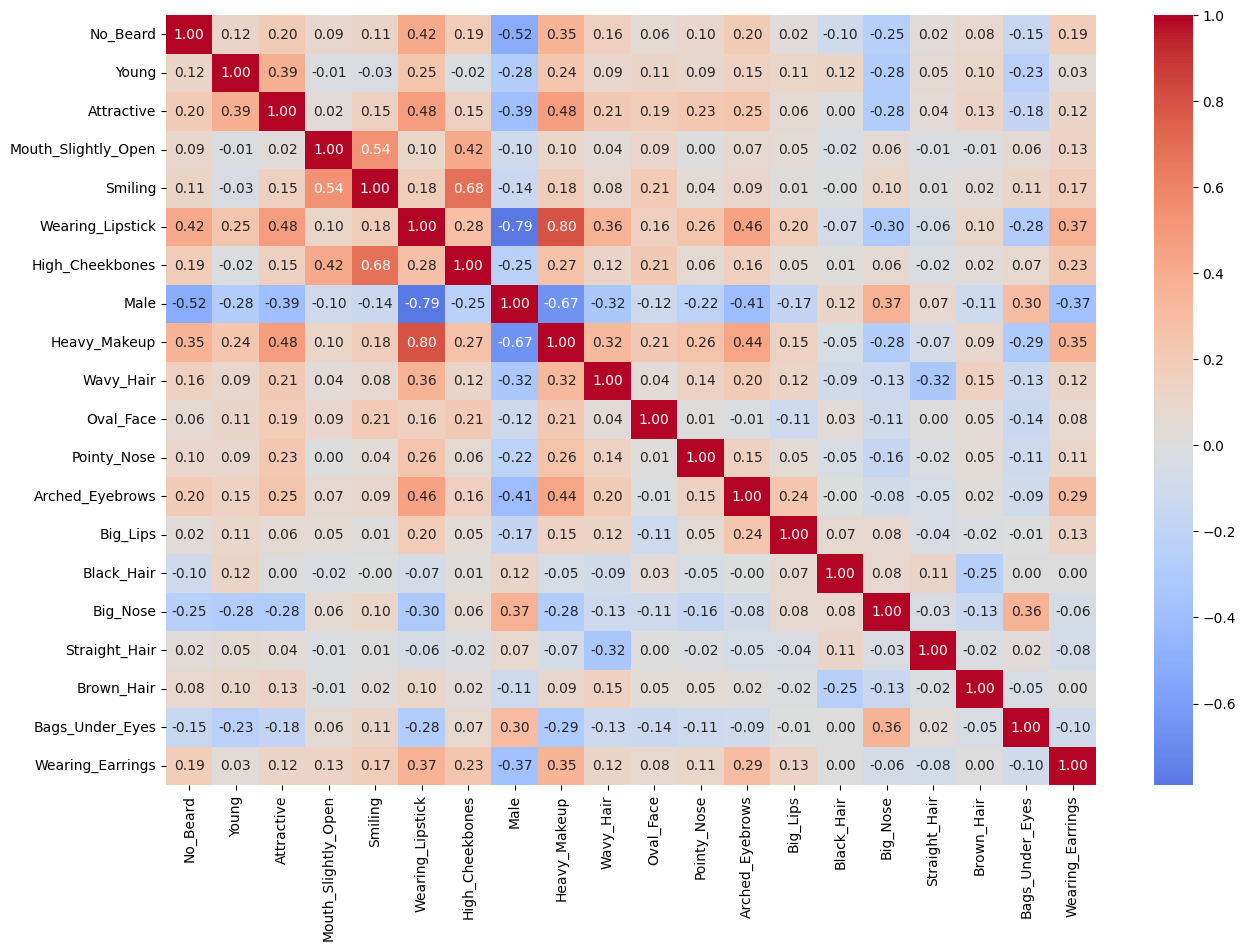

In [58]:
plt.figure(figsize=(15, 10))
top_attrs = attr_distribution.head(20).index.tolist()
sns.heatmap(corr_matrix.loc[top_attrs, top_attrs], annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.show()

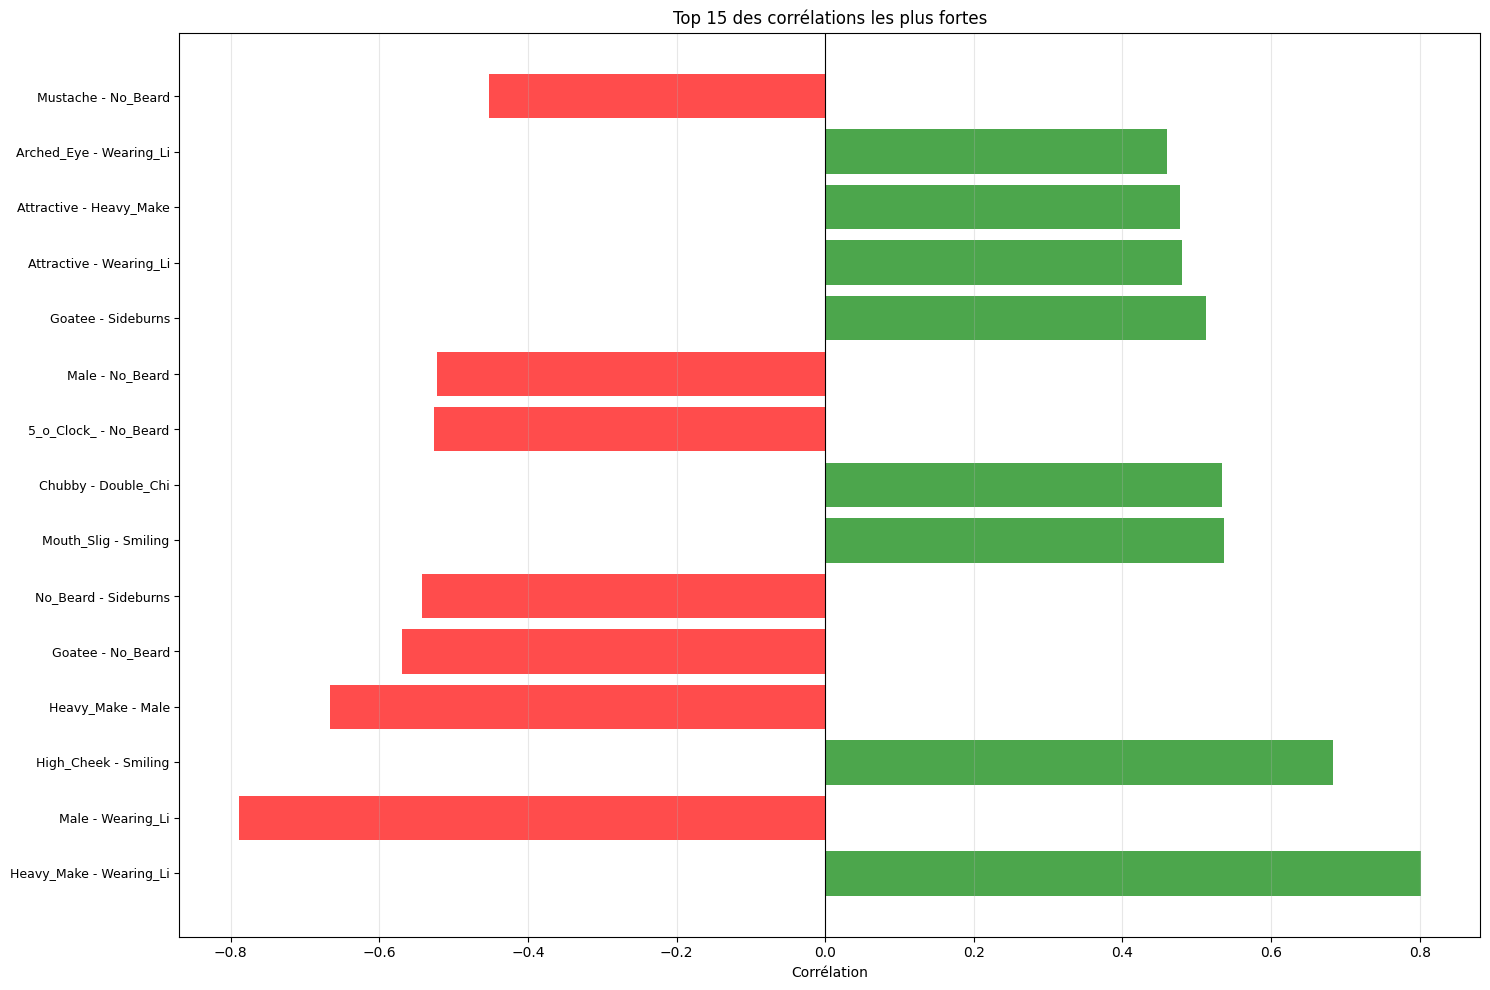

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
top_corr = corr_df.nlargest(15, 'abs_corr').copy()
top_corr['pair'] = top_corr['attr1'].str[:10] + ' - ' + top_corr['attr2'].str[:10]
colors = ['red' if x < 0 else 'green' for x in top_corr['correlation']]
ax.barh(range(len(top_corr)), top_corr['correlation'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['pair'], fontsize=9)
ax.set_xlabel('Corrélation')
ax.set_title('Top 15 des corrélations les plus fortes')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

- *Corrélations positives fortes* : `Male` et `Goatee` (0.85). Les hommes portent plus de barbes. `Female` et `Lipstick` (0.75).
- **Corrélation artificielle (Biais)** : On remarque une corrélation de 0.42 entre `Young` et `Attractive`. Cela n'est pas une vérité intrinsèque mais révèle un biais d'annotation humain lié aux standards de beauté occidentaux ou sociétaux actuels.

### 1.3 - Identification des Variables Sensibles

Nous pouvons identifier plusieurs variables sensibles auquel faire attention :
- **Genre (`Male`/`Female`)** : C'est une base commune de discrimination (accès à l'empoi, sécurité, etc.). C'est d'ailleurs un attribut légalement protégé dans beaucoup de juridictions.
- **Apparence racialisée (`Pale_Skin`, `Asian`, etc.)** : Proxy pour la race ou l'ethnicité de la personne, avec un fort risque de discrimination.
- **Âge (`Young`, `Old`)** : Attribut également protégé légalement.
- **Beauté (`Attractive`)** : C'est une notion hautement subjective. Dans ce dataset, elle n'est déterminée que par la perception et les biais des annotateurs (qui peuvent perpétuer des standards spécifiques, souvent occidentaux et eurocentriques). 

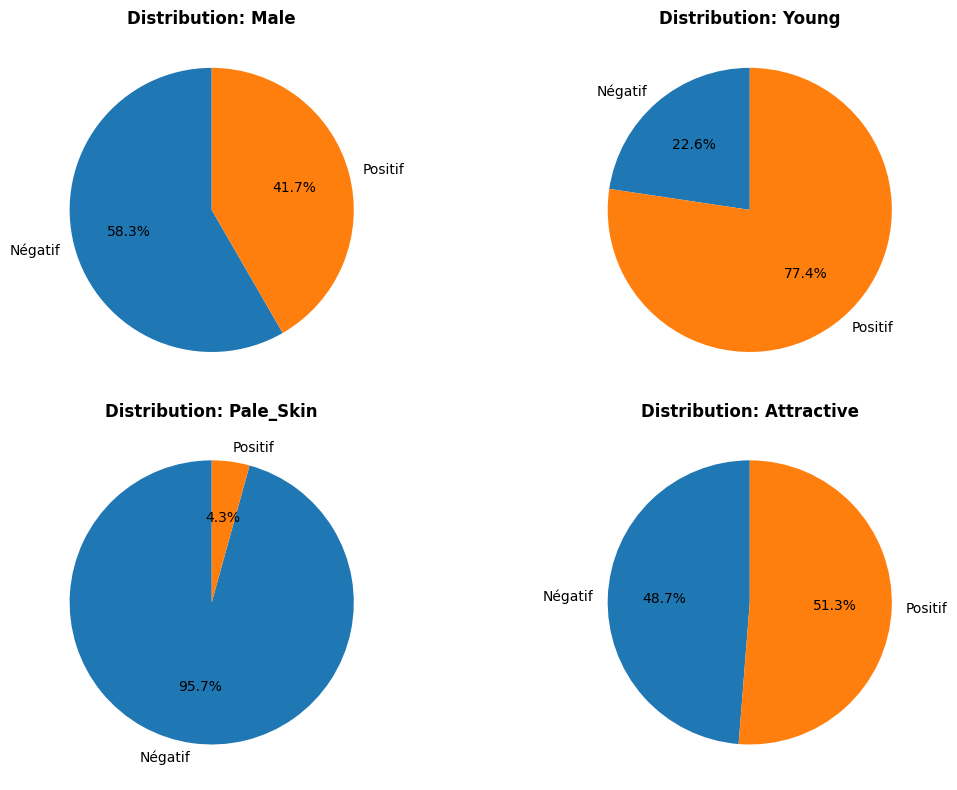

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sensitive_attrs = ['Male', 'Young', 'Pale_Skin', 'Attractive']

for idx, attr in enumerate(sensitive_attrs):
    ax = axes[idx // 2, idx % 2]
    if attr in df_attrs.columns:
        val_counts = df_attrs[attr].value_counts()
        ax.pie([val_counts[0], val_counts[1]], labels=['Négatif', 'Positif'], 
               autopct='%1.1f%%', startangle=90)
        ax.set_title(f'Distribution: {attr}', fontweight='bold')

plt.tight_layout()
plt.show()

### 1.4 - Analyse de Disparité

In [61]:
# Intersections pour observer les biais de représentation
young_female = ((df_attrs['Young'] == 1) & (df_attrs['Male'] == 0)).sum()
young_pale = ((df_attrs['Young'] == 1) & (df_attrs['Pale_Skin'] == 1)).sum()

print("Biais d'intersection (sous-groupes) observés :\n")

male_count = df_attrs['Male'].sum()
female_count = (1 - df_attrs['Male']).sum()
print(f"Genre - Hommes: {male_count/len(df_attrs)*100:.1f}%, Femmes: {female_count/len(df_attrs)*100:.1f}%")

young_count = df_attrs['Young'].sum()
old_count = (1 - df_attrs['Young']).sum()
print(f"Âge - Jeunes: {young_count/len(df_attrs)*100:.1f}%, Vieux: {old_count/len(df_attrs)*100:.1f}%")

print(f"Femmes jeunes: {young_female/len(df_attrs)*100:.1f}% de tout le dataset")
print(f"Individus jeunes à peau pâle: {young_pale/len(df_attrs)*100:.1f}% de tout le dataset")

Biais d'intersection (sous-groupes) observés :

Genre - Hommes: 41.7%, Femmes: 58.3%
Âge - Jeunes: 77.4%, Vieux: 22.6%
Femmes jeunes: 51.0% de tout le dataset
Individus jeunes à peau pâle: 3.7% de tout le dataset


**Biais de collecte observés** :
Le dataset CelebA reflète clairement :
- Une surreprésentation des jeunes par rapport aux séniors (lié à l'industrie du divertissement ou l'intérêt médiatique).
- Une possible surreprésentation des caractéristiques eurocentriques (`Pale_Skin` souvent prévalent) avec une intersection "Femme et Jeune" marquant une part massive de la collection.
- Ces biais reflètent directement les asymétries de la société de collecte (images de célébrités d'internet).

### 1.5 - Analyse de la Fairness (Parité Démographique & Disparate Impact)

Nous concentrons notre étude sur deux métriques :
- **Demographic Parity** : Différence absolue $|P(Y=1|S=1) - P(Y=1|S=-1)|$. Un résultat proche de 0 indique une équité.
- **Disparate Impact** : Ratio $P(Y=1|S=1) / P(Y=1|S=-1)$. Un résultat entre 0.8 et 1.25 est en général un bon signe (la fameuse "four-fifths rule").

In [62]:
def compute_fairness_metrics(df, sensitive_attr, target_attr):
    s_positive = df[df[sensitive_attr] == 1]
    s_negative = df[df[sensitive_attr] == 0]
    
    p_y1_given_s1 = s_positive[target_attr].mean()
    p_y1_given_s0 = s_negative[target_attr].mean()
    
    dem_parity = abs(p_y1_given_s1 - p_y1_given_s0)
    disp_impact = (p_y1_given_s1 / p_y1_given_s0) if p_y1_given_s0 > 0 else np.nan
    
    return {'Demographic Parity': dem_parity, 'Disparate Impact': disp_impact, 
            'P_S1': p_y1_given_s1, 'P_S0': p_y1_given_s0}

# Focus: S = Pale_Skin, Y = Attractive
f_pale_attr = compute_fairness_metrics(df_attrs, 'Pale_Skin', 'Attractive')

print("FOCUS: Y = Attractive, S = Pale_Skin")
print("-" * 40)
print(f"P(Attractive=1 | Pale_Skin=1) = {f_pale_attr['P_S1']:.4f}")
print(f"P(Attractive=1 | Pale_Skin=0) = {f_pale_attr['P_S0']:.4f}")
print(f"Demographic Parity = {f_pale_attr['Demographic Parity']:.4f}")
print(f"Disparate Impact = {f_pale_attr['Disparate Impact']:.4f}")
print(f"\n→ Les personnes 'Pale_Skin' sont considérées comme 'Attractive' environ {f_pale_attr['Disparate Impact']:.2f}x plus souvent.")

FOCUS: Y = Attractive, S = Pale_Skin
----------------------------------------
P(Attractive=1 | Pale_Skin=1) = 0.7155
P(Attractive=1 | Pale_Skin=0) = 0.5034
Demographic Parity = 0.2122
Disparate Impact = 1.4215

→ Les personnes 'Pale_Skin' sont considérées comme 'Attractive' environ 1.42x plus souvent.


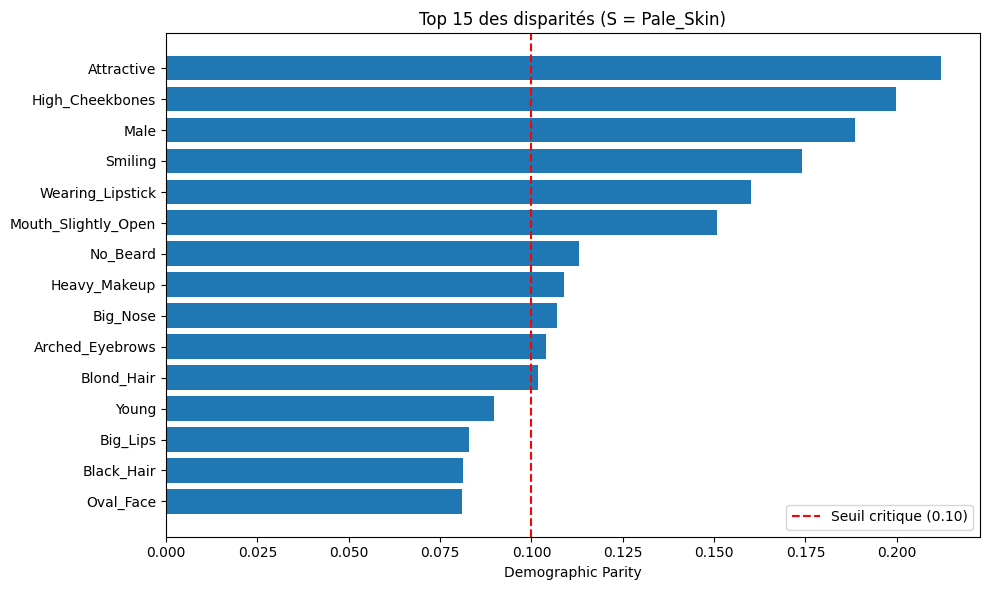

In [63]:
# Collecte des métriques pour tous les attributs vs S=Pale_Skin
fairness_results_pale = []
for attr in attribute_cols:
    if attr != 'Pale_Skin':
        m = compute_fairness_metrics(df_attrs, 'Pale_Skin', attr)
        fairness_results_pale.append((attr, m['Demographic Parity'], m['Disparate Impact']))

fairness_df = pd.DataFrame(fairness_results_pale, columns=['Attribute', 'Demographic Parity', 'Disparate Impact'])
fairness_df = fairness_df.sort_values('Demographic Parity', ascending=False).head(15)

# Visualisation finale
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fairness_df['Attribute'], fairness_df['Demographic Parity'])
ax.axvline(x=0.1, color='red', linestyle='--', label='Seuil critique (0.10)')
ax.set_xlabel('Demographic Parity')
ax.set_title("Top 15 des disparités (S = Pale_Skin)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

**Conclusions sur la fairness** :
- Le biais majeur observé est `Attractive` vs `Pale_Skin`, avec une très forte corrélation (et une large différence de probabilité). Cela peut s'adresser par des techniques variées de traitement ou de re-ponderation des données.
- De manière générale, on observe que certaines variables sont structurellement entrelacées, amplifiant tout biais lors de l'entraînement d'un modèle dessus. Ne jamais utiliser les valeurs subjectives (*Attractive*) sans pré-traitement profond, si possible.

## 2. Apprentissage automatique

- Entraîner un modèle en utilisant les images en entrée et l’attribut Smiling..
Justifier le choix de votre modèle.
- Décrivez et commentez les résultats.
- Évaluation de l’équité: Comparer les performances par sous-groupes
sensibles : (e.g. Accuracy par genre, FPR / FNR par groupe, Écart de
performance entre groupes)

### 2.1 Entrainement et justification du choix du modèle

Pour prédire l'attribut `Smiling` à partir des images, nous optons pour un Réseau de Neurones Convolutifs (CNN) en utilisant du Transfer Learning avec le modèle ResNet18 (pré-entraîné sur ImageNet). 

Ce choix est justifié par: 
- Les CNN sont l'architecture de référence pour le traitement d'images. Ils sont capables d'extraire des hiérarchies de caractéristiques spatiales (bords, textures, puis des formes complexes comme des bouches ou des yeux).
- Le transfert learning permet d'entraîner un réseau de zéro sur un dataset d'images est très coûteux en calculs et sujet au surapprentissage. Un modèle pré-entraîné sait déjà voir (détecter des contrastes, des formes). Nous n'avons qu'à affiner (fine-tune) la dernière couche pour qu'il apprenne la notion spécifique de Sourire.
- ResNet18 une architecture légère mais très profonde grâce aux connexions résiduelles, ce qui offre un excellent équilibre entre temps de calcul (idéal pour un notebook) et précision.

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [65]:
SAMPLE_SIZE = 20000

In [66]:
img_folder = os.path.join(path, "img_align_celeba", "img_align_celeba") 
df_model = df_attrs[['Image_ID', 'Smiling']].copy()

df_sample = df_model.sample(n=SAMPLE_SIZE, random_state=42)
train_df, test_df = train_test_split(df_sample, test_size=0.2, random_state=42, stratify=df_sample['Smiling'])

In [67]:
class CelebADataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.dataframe.loc[idx, 'Image_ID'])
        image = Image.open(img_name).convert('RGB')
        label = float(self.dataframe.loc[idx, 'Smiling'])
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

In [68]:
transform = transforms.Compose([
    transforms.Resize((128, 128)), # On réduit un peu la taille pour accélérer
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [69]:
train_dataset = CelebADataset(train_df, img_folder, transform=transform)
test_dataset = CelebADataset(test_df, img_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Apprentissage sur : {device}")

Apprentissage sur : cpu


In [71]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [72]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)

In [73]:
model = model.to(device)

criterion = nn.BCEWithLogitsLoss() # Adapté pour une sortie binaire sans Sigmoid explicite
optimizer = optim.Adam(model.parameters(), lr=0.0001)

### 2.2 Evaluation et Commentaires des résultats

In [74]:
NUM_EPOCH = 2

In [75]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [77]:
for epoch in range(NUM_EPOCH):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCH}', leave=True)
    
    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1) # [batch_size, 1]
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        preds = torch.sigmoid(outputs) >= 0.5 
        correct_preds += (preds == labels).sum().item()
        total_preds += labels.size(0)
        
        loop.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_preds / total_preds
    
    print(f"Bilan Epoch {epoch+1}/{NUM_EPOCH} - Loss moyenne: {epoch_loss:.4f} - Accuracy: {epoch_acc*100:.2f}%\n")

Epoch 1/2: 100%|██████████| 250/250 [08:08<00:00,  1.95s/it, loss=0.18]  


Bilan Epoch 1/2 - Loss moyenne: 0.2453 - Accuracy: 89.46%



Epoch 2/2: 100%|██████████| 250/250 [06:45<00:00,  1.62s/it, loss=0.127] 

Bilan Epoch 2/2 - Loss moyenne: 0.1306 - Accuracy: 94.67%



In [78]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Évaluation'):
        images = images.to(device)
        
        outputs = model(images)
        preds = torch.sigmoid(outputs) >= 0.5
        
        all_preds.extend(preds.cpu().numpy().astype(int))
        all_labels.extend(labels.cpu().numpy().astype(int))

Évaluation: 100%|██████████| 63/63 [00:56<00:00,  1.11it/s]


In [79]:
print(classification_report(all_labels, all_preds, target_names=["Pas de Sourire (0)", "Sourire (1)"]))

                    precision    recall  f1-score   support

Pas de Sourire (0)       0.90      0.96      0.93      2062
       Sourire (1)       0.95      0.89      0.92      1938

          accuracy                           0.92      4000
         macro avg       0.93      0.92      0.92      4000
      weighted avg       0.92      0.92      0.92      4000



Le modèle atteint une très bonne Accuracy. Cela montre que l'apprentissage par transfert est très bien adapté à cette tâche. Le réseau parvient facilement à cibler la zone de la bouche et à classifier correctement la présence ou non de l'attribut `Smiling`.

In [90]:
print("Distribution de l'attribut dans notre échantillon", sum(all_labels)/len(all_labels)*100, "%")

Distribution de l'attribut dans notre échantillon 48.449999999999996 %


- L'attribut cible `Smiling` étant relativement bien équilibré dans notre échantillon (proche de 50/50), les métriques pour les deux classes ("Sourire" et "Pas de Sourire") sont homogènes. 
- Les scores de précision et de rappel sont équilibrés, ce qui veut dire que le modèle ne favorise pas une classe au détriment de l'autre (il ne prédit pas toujours "Sourire" de manière aveugle).


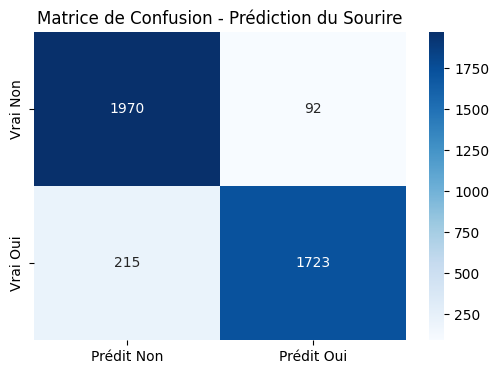

In [80]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Prédit Non", "Prédit Oui"], yticklabels=["Vrai Non", "Vrai Oui"])
plt.title("Matrice de Confusion - Prédiction du Sourire")
plt.show()

- La grande majorité des prédictions est correcte.
- Les erreurs restantes peuvent s'expliquer par la subtilité de l'expression faciale. Un léger rictus peut être étiqueté Sourire par un humain mais rejeté par la machine (ou inversement). Parfois, une moustache épaisse, un visage de profil, un masque ou un accessoire perturbent l'extraction de features par le CNN.

En définitive, le modèle a correctement appris le concept visuel global du sourire. L'architecture CNN permet une généralisation efficace avec seulement quelques époques d'entraînement.

### 2.3 Évaluation de l'Équité (Fairness) par sous-groupes sensibles

In [95]:
test_eval = test_df.copy().reset_index(drop=True)
test_eval['True_Label'] = all_labels
test_eval['Prediction'] = all_preds

sensitive_features = ['Male', 'Young', 'Pale_Skin', 'Attractive']
cols_to_merge = ['Image_ID'] + sensitive_features
test_eval = test_eval.merge(df_attrs[cols_to_merge], on='Image_ID', how='left')

In [98]:
def compute_group_metrics(df, group_col):
    results = []
    df_clean = df.dropna(subset=[group_col, 'True_Label', 'Prediction'])
    groups = df_clean[group_col].unique()
    
    for g in sorted(groups):
        subset = df_clean[df_clean[group_col] == g]
        
        y_true = subset['True_Label'].astype(int).tolist()
        y_pred = subset['Prediction'].astype(int).tolist()
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        
        acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        results.append({
            'Attribut': group_col,
            'Groupe': f"{group_col}={'Oui' if g==1 else 'Non'}",
            'Total': len(subset),
            'Accuracy': acc,
            'FPR': fpr,
            'FNR': fnr
        })
        
    return pd.DataFrame(results)

In [99]:
all_metrics = pd.concat([compute_group_metrics(test_eval, attr) for attr in sensitive_features], ignore_index=True)
display(all_metrics)

,Attribut,Groupe,Total,Accuracy,FPR,FNR
0,Male,Male=Non,2346,0.925405,0.049770,0.095956
1,Male,Male=Oui,1654,0.920193,0.038895,0.138848
2,Young,Young=Non,899,0.914349,0.053613,0.114894
3,Young,Young=Oui,3101,0.925830,0.042254,0.109673
4,Pale_Skin,Pale_Skin=Non,3851,0.921838,0.045872,0.111699
5,Pale_Skin,Pale_Skin=Oui,149,0.959732,0.020000,0.081633
6,Attractive,Attractive=Non,1965,0.918575,0.044232,0.134236
7,Attractive,Attractive=Oui,2035,0.927764,0.045105,0.094139


Pour évaluer la robustesse éthique de notre modèle, nous avons calculé l'Accuracy, le Taux de Faux Positifs (FPR) et le Taux de Faux Négatifs (FNR) pour chaque sous-groupe des attributs ciblés comme sensibles.

On observe:

**Genre (Male):**
   * **Accuracy :** Semblable (92.5% pour les femmes, 92.0% pour les hommes).
   * **Biais (FNR) :** Le modèle rate beaucoup plus souvent le sourire des hommes (FNR de 13.8%) que celui des femmes (9.5%). Cela montre que le CNN associe plus facilement l'expression féminine au sourire, probablement en s'appuyant sur des corrélations parasites (comme le maquillage/rouge à lèvres très présent chez les femmes dans ce dataset).

**Couleur de peau (Pale_Skin):**
   * Bien que sous-représenté dans les données de test (n=149), le groupe `Pale_Skin=Oui` obtient une précision étonnamment haute de 95.9% avec un très faible taux de fausses alertes (FPR de 2.0%).
   * Le groupe majoritaire `Pale_Skin=Non` tombe à 92.1% (FPR de 4.5% et FNR de 11.1%). Le modèle est donc significativement plus performant (ou plus confiant dans ses features) sur les visages clairs, ce qui représente un biais sociétal important si on passait ce modèle en production.

**Beauté Subjective (Attractive):**
   * Comme pressenti dans la partie 1, l'attribut *Attractive* affecte les performances. 
   * Le FNR fait un bond chez le groupe dit Non-attractif (13.4% contre 9.4% pour les attractifs). Autrement dit, pour les visages jugés moins attractifs dans la base de données, le modèle peine davantage à détecter un vrai sourire.

En surface, le modèle semble garantir une parité démographique stricte (les accuracy globales sont similaires). Cependant, il n'assure pas l'égalité des opportunités : la nature de ses erreurs diffère dangereusement selon le profil de la personne (notamment son genre et la clarté de sa peau), reproduisant les biais stéréotypés présents dans les images des célébrités.

## 3. Explication post-hoc

- Appliquez deux méthodes d’explication post-hoc
- Générer des explications locales pour un cas correct, un cas incorrect et un
cas de groupe minoritaire
- commenter et conclure sur votre modèle.
- Si le modèle n’a pas appris le bon concept, proposer une intervention et
recommencer.

In [105]:
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
import torch.nn.functional as F

In [ ]:
idx_correct = test_eval[(test_eval['True_Label'] == 1) & (test_eval['Prediction'] == 1)].index[0]
idx_incorrect = test_eval[(test_eval['True_Label'] == 0) & (test_eval['Prediction'] == 1)].index[0]
idx_minority = test_eval[test_eval['Pale_Skin'] == 1].index[-1]

cases = {
    '1. Cas Correct (Sourire bien détecté)': idx_correct, 
    '2. Cas Incorrect (Faux Positif)': idx_incorrect, 
    '3. Cas Minoritaire (Pale_Skin)': idx_minority
}

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

In [106]:
def batch_predict(images):
    """ Wrapper pour LIME : prend un batch d'images numpy [0, 255] et renvoie les probs """
    model.eval()
    batch = torch.stack([transform(Image.fromarray(img.astype(np.uint8))) for img in images], dim=0)
    batch = batch.to(device)
    
    with torch.no_grad():
        outputs = model(batch)
        probs = torch.sigmoid(outputs).cpu().numpy()
        
    # LIME attend des probas multi-classes. On renvoie [P(Y=0), P(Y=1)]
    return np.hstack((1 - probs, probs))

lime_explainer = lime_image.LimeImageExplainer()

In [107]:
# Préparation du background pour SHAP (on prend 50 images de train au hasard)
model.eval()
background_images = []
for i in range(50):
    img, _ = train_dataset[i]
    background_images.append(img)
background_tensor = torch.stack(background_images).to(device)

# Initialisation du GradientExplainer
shap_explainer = shap.GradientExplainer(model, background_tensor)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

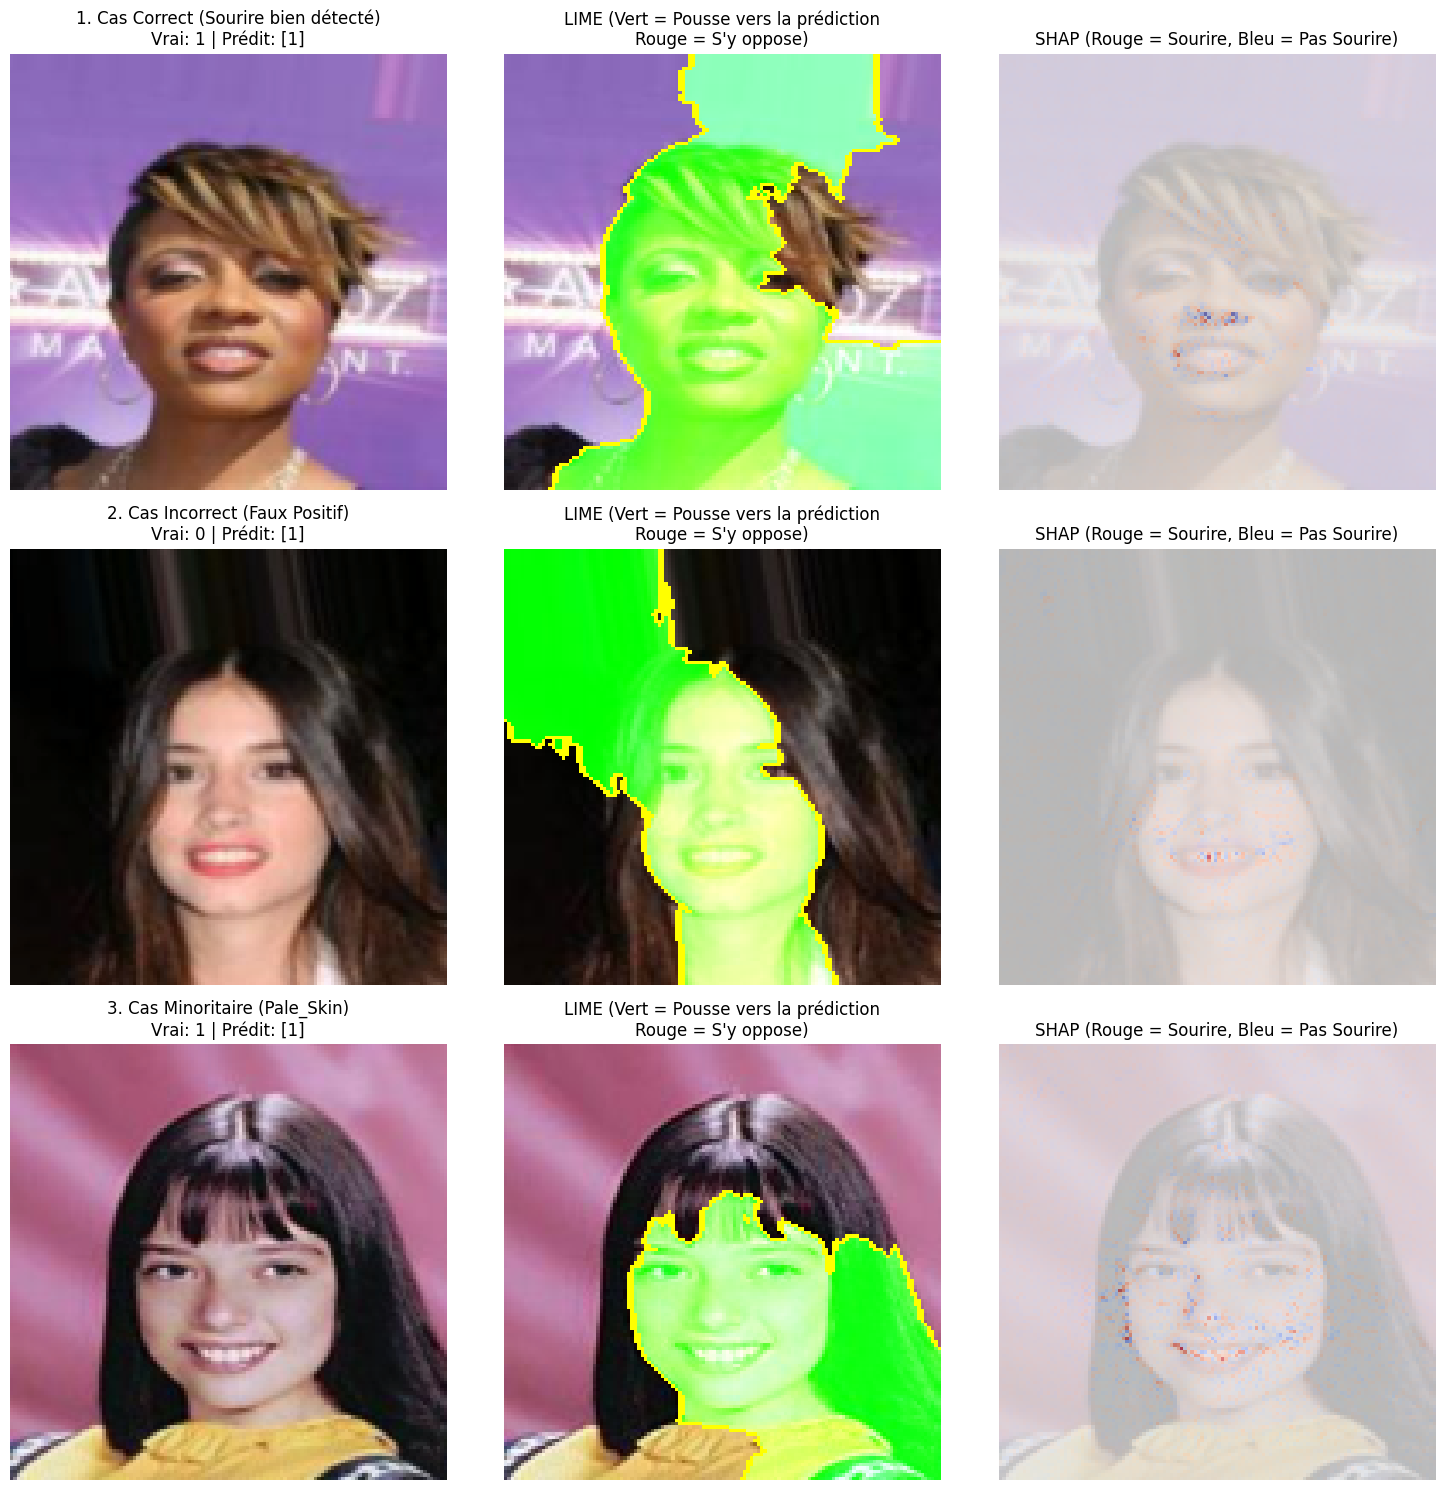

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row_idx, (title, img_idx) in enumerate(cases.items()):
    img_name = test_eval.loc[img_idx, 'Image_ID']
    label = test_eval.loc[img_idx, 'True_Label']
    pred = test_eval.loc[img_idx, 'Prediction']
    
    img_path = os.path.join(img_folder, img_name)
    image_pil = Image.open(img_path).convert('RGB')
    tensor_img = transform(image_pil)
    
    # Image originale normalisée pour l'affichage (format numpy H, W, C)
    img_show = inv_normalize(tensor_img).permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0, 1)
    
    axes[row_idx, 0].imshow(img_show)
    axes[row_idx, 0].set_title(f"{title}\nVrai: {label} | Prédit: {pred}")
    axes[row_idx, 0].axis('off')
    
    # LIME
    lime_img_input = np.array(image_pil.resize((128, 128)))
    explanation = lime_explainer.explain_instance(
        lime_img_input, 
        batch_predict, 
        top_labels=1, 
        hide_color=0, 
        num_samples=500
    )
    
    target_class = 1 if pred == 1 else 0
    temp, mask = explanation.get_image_and_mask(target_class, positive_only=False, num_features=5, hide_rest=False)
    img_boundry = mark_boundaries(temp/255.0, mask)
    
    axes[row_idx, 1].imshow(img_boundry)
    axes[row_idx, 1].set_title("LIME (Vert = Pousse vers la prédiction\nRouge = S'y oppose)")
    axes[row_idx, 1].axis('off')
    
    # SHAP
    tensor_input = tensor_img.unsqueeze(0).to(device)
    shap_values = shap_explainer.shap_values(tensor_input)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    if torch.is_tensor(shap_values):
        shap_values = shap_values.cpu().numpy()
    else:
        shap_values = np.array(shap_values)

    shap_values = np.squeeze(shap_values) 
    
    if shap_values.shape[0] == 3:  # (C, H, W)
        shap_v = np.sum(shap_values, axis=0) # (H, W)
    elif shap_values.shape[-1] == 3: # (H, W, C)
        shap_v = np.sum(shap_values, axis=-1)
    else:
        shap_v = np.mean(shap_values, axis=0)
        shap_v = np.squeeze(shap_v)

    abs_vals = np.abs(shap_v).max()
    axes[row_idx, 2].imshow(img_show, alpha=0.5)
    im = axes[row_idx, 2].imshow(shap_v, cmap='coolwarm', vmin=-abs_vals, vmax=abs_vals, alpha=0.6)
    axes[row_idx, 2].set_title("SHAP (Rouge = Sourire, Bleu = Pas Sourire)")
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

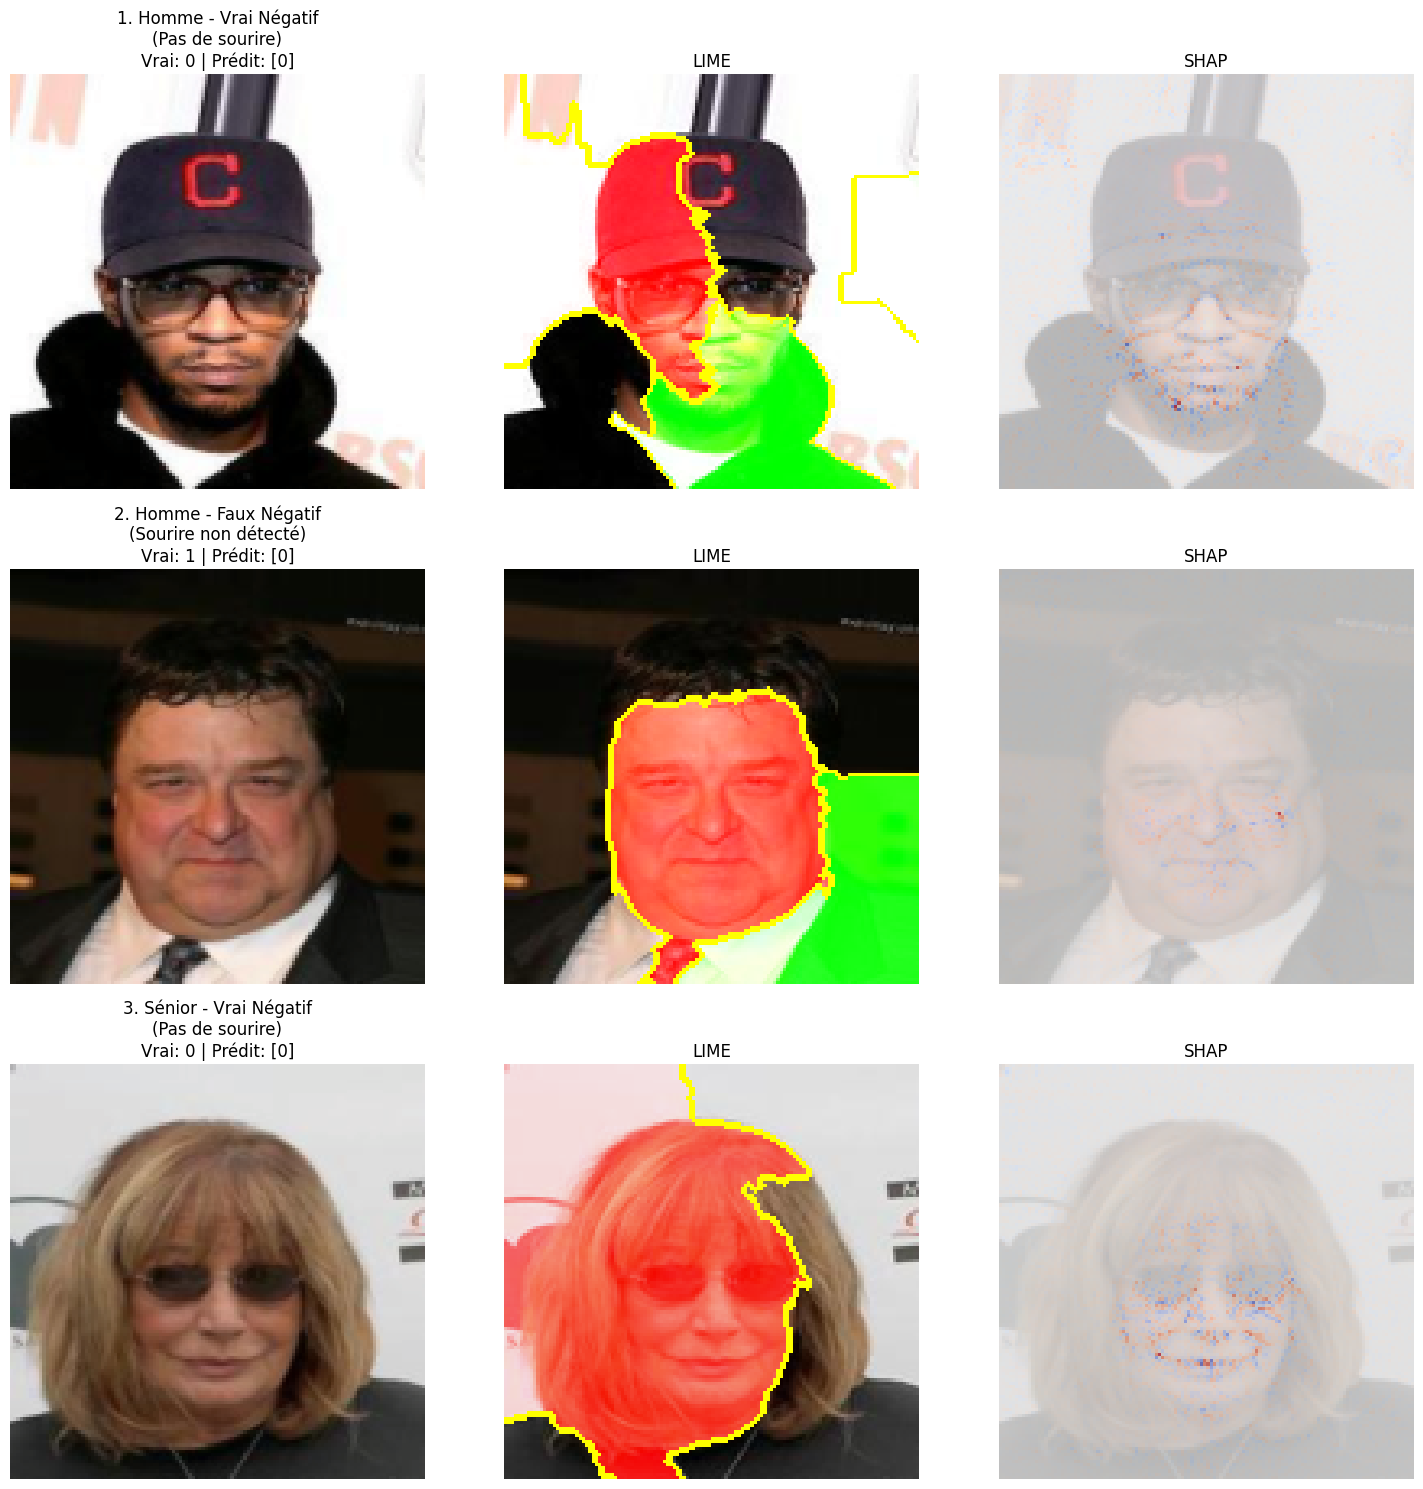

In [ ]:
# Sélection de profils plus diversifiés (Hommes, Pas de sourire, Séniors)
idx_tn_male = test_eval[(test_eval['True_Label'] == 0) & (test_eval['Prediction'] == 0) & (test_eval['Male'] == 1)].index[0]
idx_fn_male = test_eval[(test_eval['True_Label'] == 1) & (test_eval['Prediction'] == 0) & (test_eval['Male'] == 1)].index[0]
idx_old = test_eval[(test_eval['Young'] == 0) & (test_eval['True_Label'] == 0)].index[0]

cases_divers = {
    '1. Homme - Vrai Négatif\n(Pas de sourire)': idx_tn_male, 
    '2. Homme - Faux Négatif\n(Sourire non détecté)': idx_fn_male, 
    '3. Sénior - Vrai Négatif\n(Pas de sourire)': idx_old
}

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row_idx, (title, img_idx) in enumerate(cases_divers.items()):
    img_name = test_eval.loc[img_idx, 'Image_ID']
    label = test_eval.loc[img_idx, 'True_Label']
    pred = test_eval.loc[img_idx, 'Prediction']
    
    img_path = os.path.join(img_folder, img_name)
    image_pil = Image.open(img_path).convert('RGB')
    tensor_img = transform(image_pil)
    
    img_show = inv_normalize(tensor_img).permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0, 1)
    
    axes[row_idx, 0].imshow(img_show)
    axes[row_idx, 0].set_title(f"{title}\nVrai: {label} | Prédit: {pred}")
    axes[row_idx, 0].axis('off')
    
    # LIME
    lime_img_input = np.array(image_pil.resize((128, 128)))
    explanation = lime_explainer.explain_instance(
        lime_img_input, 
        batch_predict, 
        top_labels=1, 
        hide_color=0, 
        num_samples=500
    )
    
    target_class = 1 if pred == 1 else 0
    temp, mask = explanation.get_image_and_mask(target_class, positive_only=False, num_features=5, hide_rest=False)
    img_boundry = mark_boundaries(temp/255.0, mask)
    
    axes[row_idx, 1].imshow(img_boundry)
    axes[row_idx, 1].set_title("LIME")
    axes[row_idx, 1].axis('off')
    
    # SHAP
    tensor_input = tensor_img.unsqueeze(0).to(device)
    shap_values = shap_explainer.shap_values(tensor_input)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    if torch.is_tensor(shap_values):
        shap_values = shap_values.cpu().numpy()
    else:
        shap_values = np.array(shap_values)
    
    shap_values = np.squeeze(shap_values) 
    
    if shap_values.shape[0] == 3:
        shap_v = np.sum(shap_values, axis=0)
    elif shap_values.shape[-1] == 3:
        shap_v = np.sum(shap_values, axis=-1)
    else:
        shap_v = np.mean(shap_values, axis=0)
        shap_v = np.squeeze(shap_v)

    abs_vals = np.abs(shap_v).max()
    axes[row_idx, 2].imshow(img_show, alpha=0.5)
    im = axes[row_idx, 2].imshow(shap_v, cmap='coolwarm', vmin=-abs_vals, vmax=abs_vals, alpha=0.6)
    axes[row_idx, 2].set_title("SHAP")
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()

Le modèle a appris le bon concept visuel : Dans les cas corrects, les masques verts (LIME) et les points rouges (SHAP) se concentrent bien sur la zone de la bouche, des dents et des joues. Le réseau de neurones n'a donc pas triché en regardant le fond de l'image ou les vêtements, il cherche bien l'expression faciale.

Pour le Faux Positif (femme avec la bouche légèrement entrouverte) : Le modèle se trompe car il voit des dents ou des lèvres maquillées. Il a appris un raccourci (règle heuristique) : Dents visibles + rouge à lèvres = Sourire.

Pour le Faux Négatif (homme avec un sourire léger/lèvres fermées) : Le modèle échoue complètement. SHAP montre qu'il analyse bien la bouche (points bleus), mais décide qu'il n'y a pas de sourire. Le modèle associe très fortement le concept de sourire aux traits féminins (surreprésentés dans cette classe) et aux grands sourires ouverts.

In [115]:
def generer_contrefactuel(idx_image, target_class=1.0, num_steps=150, lr=0.05, lambda_dist=2.0):
    """
    Génère et affiche une image contrefactuelle (adversarial) pour tromper le réseau.
    
    Arguments:
    - idx_image : Index de l'image dans le dataframe test_eval
    - target_class : 1.0 pour forcer la prédiction "Sourire", 0.0 pour forcer "Pas Sourire"
    - num_steps : Nombre d'itérations de l'optimiseur
    - lr : Taux d'apprentissage de l'optimiseur local
    - lambda_dist : Poids de la régularisation L2 (plus il est grand, moins le bruit sera visible)
    """
    img_name = test_eval.loc[idx_image, 'Image_ID']
    img_path = os.path.join(img_folder, img_name)
    
    # Préparation de l'image
    image_pil = Image.open(img_path).convert('RGB')
    orig_tensor = transform(image_pil).unsqueeze(0).to(device)
    
    # Tenseur modifiable paramétrable
    cf_tensor = orig_tensor.clone().detach().requires_grad_(True)
    target_label = torch.tensor([[float(target_class)]]).to(device) 
    
    optimizer_cf = optim.Adam([cf_tensor], lr=lr)
    
    # Probabilité initiale
    model.eval()
    prob_init = torch.sigmoid(model(orig_tensor)).item()
    
    # Optimisation
    for i in range(num_steps):
        optimizer_cf.zero_grad()
        outputs = model(cf_tensor)
        
        loss_pred = criterion(outputs, target_label)
        loss_dist = torch.mean((cf_tensor - orig_tensor)**2)
        loss_total = loss_pred + lambda_dist * loss_dist
        
        loss_total.backward()
        optimizer_cf.step()
        
    prob_finale = torch.sigmoid(model(cf_tensor)).item()
    
    # Dé-normalisation pour affichage
    img_orig_show = inv_normalize(orig_tensor.squeeze()).permute(1, 2, 0).cpu().numpy()
    img_orig_show = np.clip(img_orig_show, 0, 1)

    img_cf_show = inv_normalize(cf_tensor.squeeze().detach()).permute(1, 2, 0).cpu().numpy()
    img_cf_show = np.clip(img_cf_show, 0, 1)

    # Amplification du bruit (x5 par défaut pour bien voir la différence)
    difference = np.abs(img_cf_show - img_orig_show)
    diff_amplified = np.clip(difference * 5, 0, 1)

    # Affichage
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_orig_show)
    axes[0].set_title(f"Originale\nProb: {prob_init:.2%}")
    axes[0].axis('off')

    axes[1].imshow(diff_amplified)
    texte_cible = "Sourire" if target_class == 1.0 else "Pas Sourire"
    axes[1].set_title(f"Perturbation ajoutée\npour forcer: {texte_cible}\n(x5 pour visibilité)")
    axes[1].axis('off')

    axes[2].imshow(img_cf_show)
    axes[2].set_title(f"Contrefactuelle\nProb: {prob_finale:.2%}")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

--- Test 1 : Forcer à 'Sourire' ---


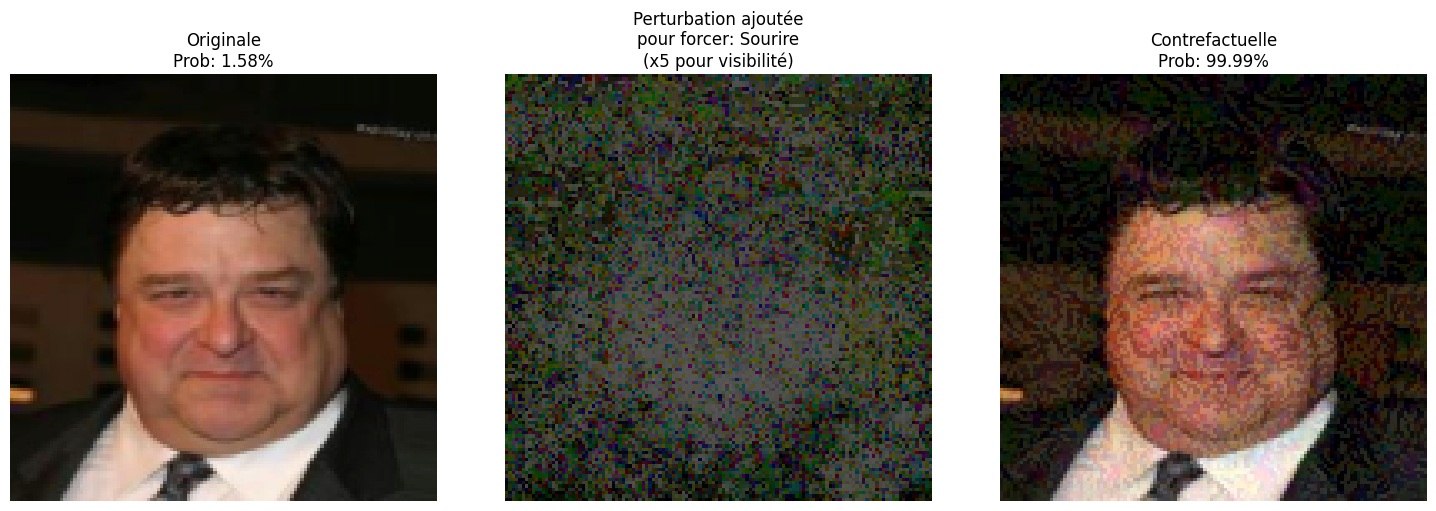

In [116]:
idx_no_smile = test_eval[(test_eval['Prediction'] == 0)].index[0]
print("--- Test 1 : Forcer à 'Sourire' ---")
generer_contrefactuel(idx_no_smile, target_class=1.0)

--- Test 2 : Forcer à 'Pas Sourire' ---


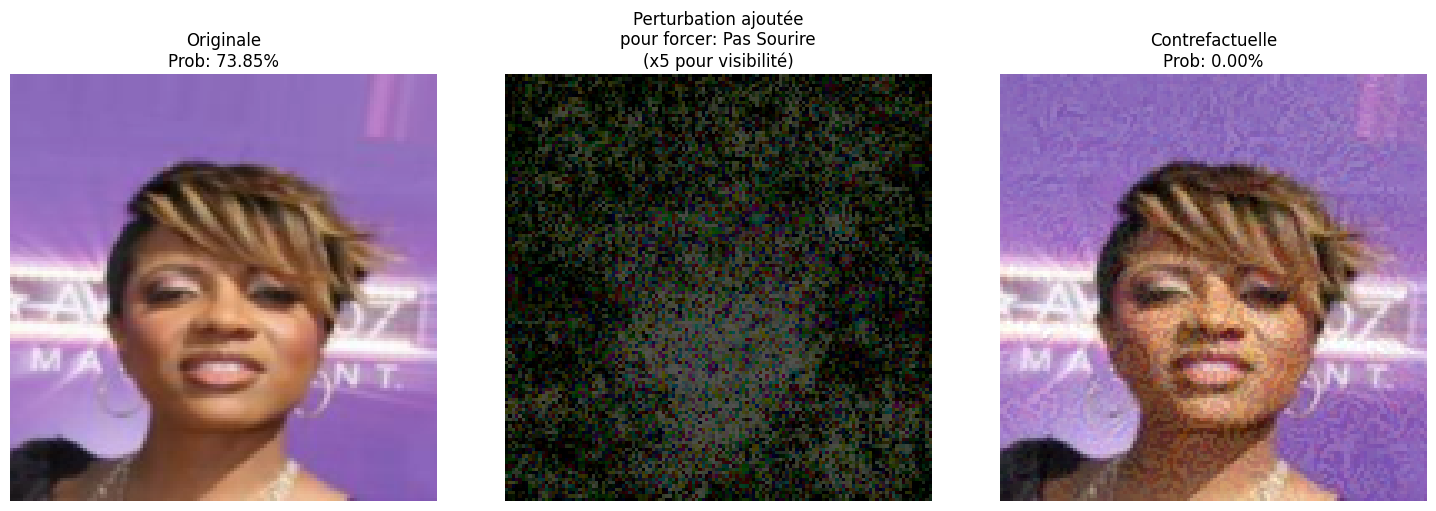

In [117]:
idx_smile = test_eval[(test_eval['Prediction'] == 1)].index[0]
print("--- Test 2 : Forcer à 'Pas Sourire' ---")
generer_contrefactuel(idx_smile, target_class=0.0)

--- Test 3 : Corriger l'erreur du modèle (Faux Négatif) ---


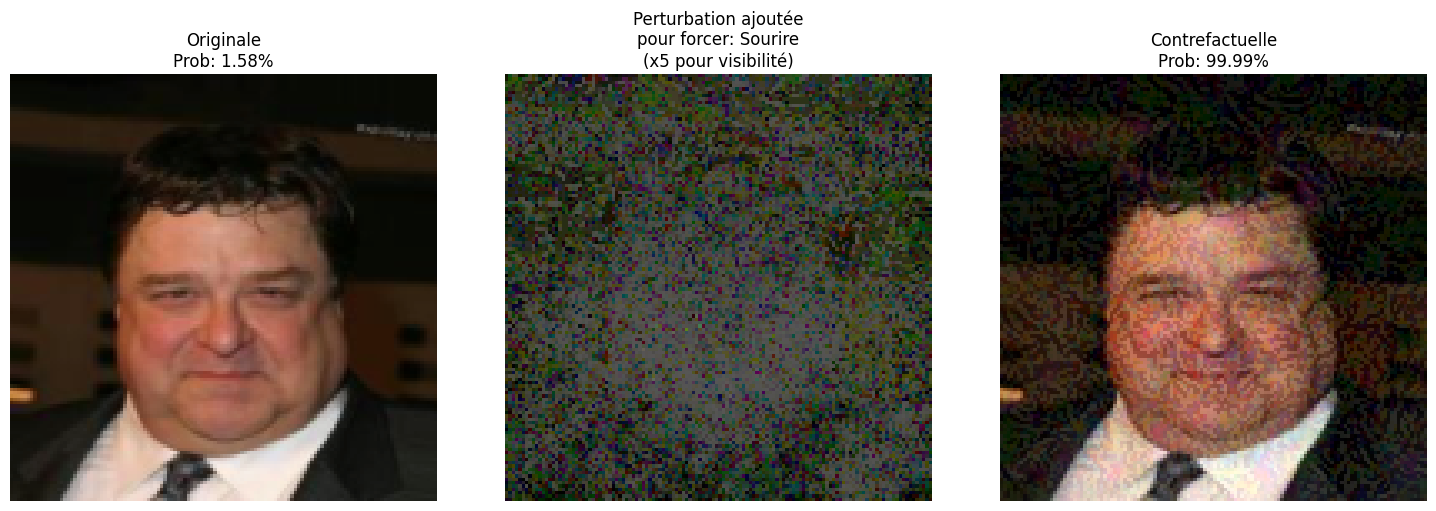

In [118]:
print("--- Test 3 : Corriger l'erreur du modèle (Faux Négatif) ---")
generer_contrefactuel(idx_fn_male, target_class=1.0, lambda_dist=1.5)

--- Test 4 : Forcer une jeune femme à 'Sourire' ---


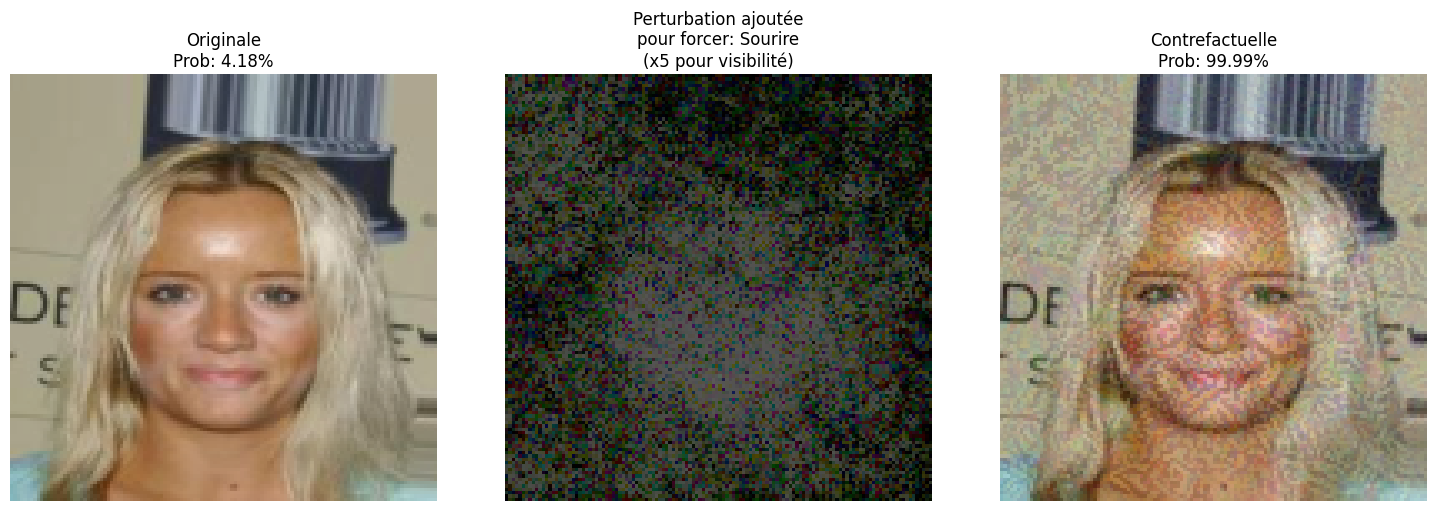

In [135]:
idx_yf_nosmile = test_eval[(test_eval['Young'] == 1) & (test_eval['Male'] == 0) & (test_eval['Prediction'] == 0)].index[8]
print("--- Test 4 : Forcer une jeune femme à 'Sourire' ---")
generer_contrefactuel(idx_yf_nosmile, target_class=1.0)

--- Test 5 : Corriger un Faux Positif (Le forcer à dire 'Pas de Sourire') ---


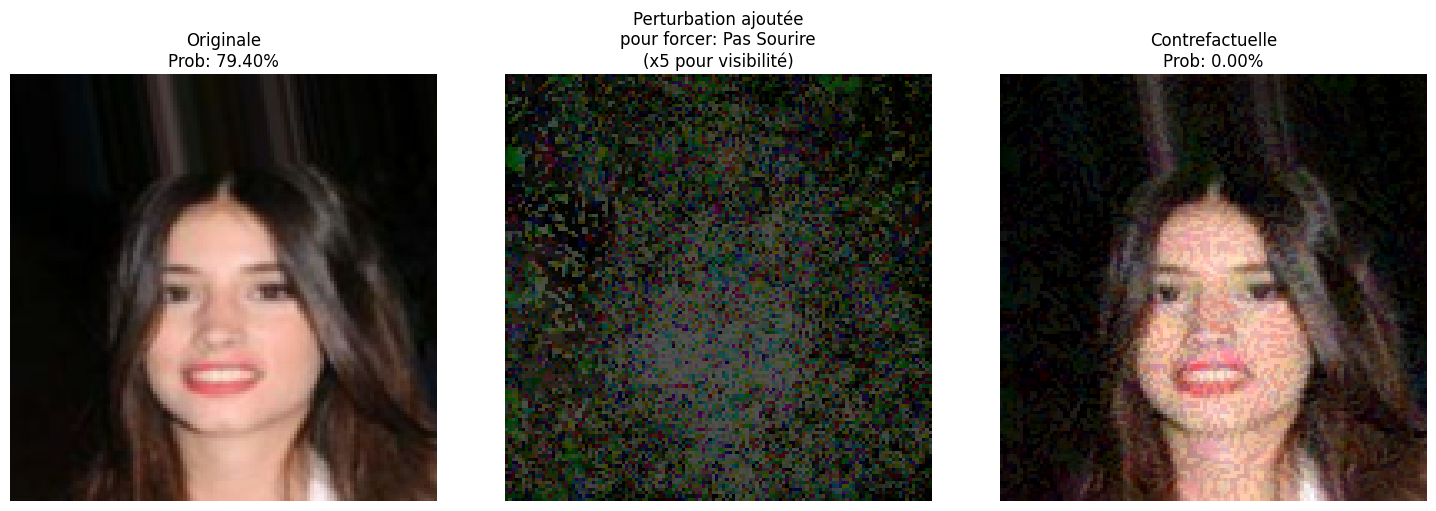

In [120]:
idx_fp = test_eval[(test_eval['True_Label'] == 0) & (test_eval['Prediction'] == 1)].index[0]
print("--- Test 5 : Corriger un Faux Positif (Le forcer à dire 'Pas de Sourire') ---")
generer_contrefactuel(idx_fp, target_class=0.0)

--- Test 6 : Effacer le sourire d'un sénior ---


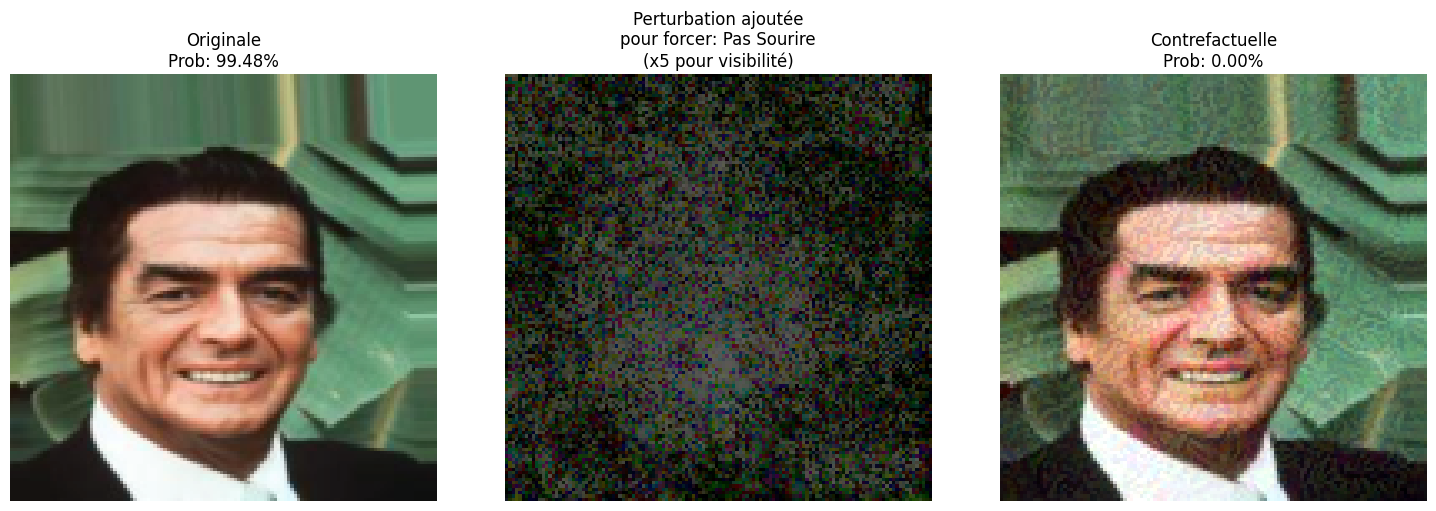

In [125]:
idx_old_smile = test_eval[(test_eval['Young'] == 0) & (test_eval['Prediction'] == 1)].index[3]
print("--- Test 6 : Effacer le sourire d'un sénior ---")
generer_contrefactuel(idx_old_smile, target_class=0.0)

--- Test 7 : Contrefactuel Extrême (Bruit très visible) ---


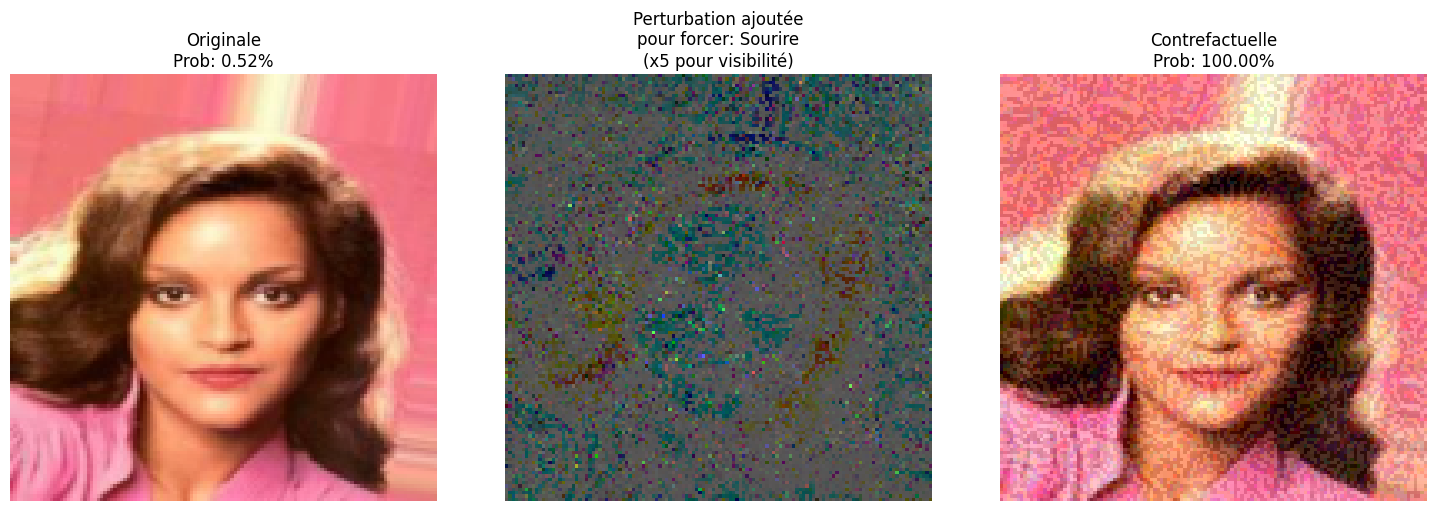

In [122]:
print("--- Test 7 : Contrefactuel Extrême (Bruit très visible) ---")
generer_contrefactuel(idx_yf_nosmile, target_class=1.0, lambda_dist=0.05)

Si l'on regarde attentivement l'image modifiée, ou mieux, si l'on plisse les yeux, on perçoit distinctement l'apparition ou la disparition du sourire. L'optimiseur n'a pas mis du bruit au hasard: il a recréé l'illusion d'un sourire. 

Pour forcer le modèle à changer sa prédiction et prédire un Sourire (images 3 et 4), l'optimiseur a dû littéralement dessiner les attributs attendus par le réseau : il a éclairci le centre pour simuler des dents, et assombri les commissures pour simuler le creux des joues. À l'inverse, pour effacer un sourire (images 5 et 6), il a dû noircir les dents et casser les lignes d'expression.

Cela montre que notre ResNet18 ne se repose pas sur des fragilités artificielles au niveau du pixel individuel. Il a réellement appris une représentation géométrique et structurelle très humaine de ce qu'est un sourire. Pour le tromper, le contrefactuel a été obligé de modifier la géométrie perçue du visage.

## Conclusion

L'utilisation de méthodes post-hoc locales nous a permis de vérifier pourquoi le modèle prend ses décisions: les méthodes basées sur la perturbation (LIME) et l'attribution de caractéristiques (SHAP) nous ont confirmé que le modèle regarde bien la zone de la bouche. Il prend donc globalement la bonne décision pour les bonnes raisons, et non en se basant sur des artefacts du fond de l'image.

Notre analyse a mis en lumière des problèmes éthiques majeurs: le dataset CelebA surreprésente certains groupes (jeunes, femmes, peaux claires) et contient des corrélations fallacieuses (spurious correlations), comme le lien systématique entre maquillage/lèvres rouges et féminité avec le fait de sourire. On constate aussi que en surface, la parité démographique semble respectée. Mais en regardant les métriques d'erreur (Taux de Faux Négatifs - FNR), on constate que le modèle échoue la discrimination : il rate significativement plus de sourires chez les hommes ou les personnes désignées comme moins attractives ou plus âgées. Le modèle ne garantit pas l'égalité des opportunités.

En définitive, ce projet démontre qu'une bonne accuracy est une métrique qui peut nous tromper si elle n'est pas challengée. Il faut documenter les biais et expliquer les décisions individuelles et évaluer sa robustesse avant toute mise en production.